In [14]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from scipy.fft import fft, fftfreq, ifft
from scipy.signal import stft
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

In [15]:
ticker = 'AAPL'
data = yf.download(ticker, start="2020""-01-01", end="2026-01-01", auto_adjust=True) # Precio de cierre ajustado
df = pd.DataFrame(data)

# Colapso de Covid-19 cambia drásticamente la varianza, estudiar desde 2023.

[*********************100%***********************]  1 of 1 completed


In [16]:
# Retornos y Volatilidad
df['Returns'] = np.log(df['Close'] / df['Close'].shift(1))
df['Volatility'] = df['Returns'].rolling(window=21).std() # Volatilidad móvil de 21 días
df.dropna(inplace=True)
print(df)

Price            Close        High         Low        Open     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2020-02-03   74.335182   75.498397   72.784224   73.285151  173788400   
2020-02-04   76.789261   76.979520   75.532118   75.936714  136616400   
2020-02-05   77.415428   78.212581   76.813348   77.913945  118826800   
2020-02-06   78.320969   78.323379   77.128855   77.685176  105425600   
2020-02-07   77.256363   78.069892   76.766314   77.821246  117684000   
...                ...         ...         ...         ...        ...   
2025-12-24  273.302216  274.919206  271.695216  271.834940   17910600   
2025-12-26  272.892975  274.859323  272.353968  273.651575   21521800   
2025-12-29  273.252350  273.851213  271.844961  272.184327   23715200   
2025-12-30  272.573578  273.571723  271.775074  272.304090   22139600   
2025-12-31  271.355835  273.172467  271.246054  272

In [17]:
# Test ADF
print(f'Test ADF para Precios de cierre de ({ticker})')
p_value = adfuller(df['Close']) # Dickey-Fuller Aumentada
print(f'P-value: {p_value[1]:.4f}')

print(f'Test ADF para Retornos logarítmicos de ({ticker})')
p_value = adfuller(df['Returns']) # Dickey-Fuller Aumentada
print(f'P-value: {p_value[1]:.4f}') 

Test ADF para Precios de cierre de (AAPL)
P-value: 0.7730
Test ADF para Retornos logarítmicos de (AAPL)
P-value: 0.0000


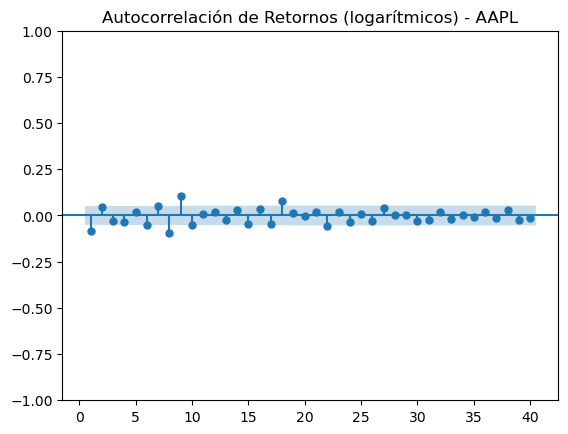

In [18]:
# Autocorrelación
plot_acf(df['Returns'], lags=40, zero=False)
plt.title(f"Autocorrelación de Retornos (logarítmicos) - {ticker}")
plt.show()

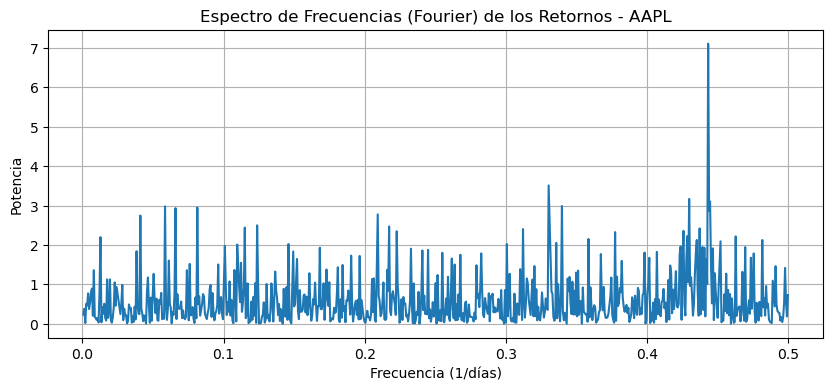

In [20]:
# Fourier (Expectro de Potencia)
# FFT sobre retornos para buscar periodicidades
N = len(df['Returns'])
returns_array = df['Returns'].values

yf_fft = fft(returns_array)
xf_freq = fftfreq(N, d=1) # 1 día de muestreo

pos_freq = xf_freq > 0 # 
frequencies = xf_freq[pos_freq]
power = np.abs(yf_fft[pos_freq]) ** 2 # Potenciar frecuencia

plt.figure(figsize=(10, 4))
plt.plot(frequencies, power)
plt.title(f"Espectro de Frecuencias (Fourier) de los Retornos - {ticker}")
plt.xlabel("Frecuencia (1/días)")
plt.ylabel("Potencia")
plt.grid(True)
plt.show()

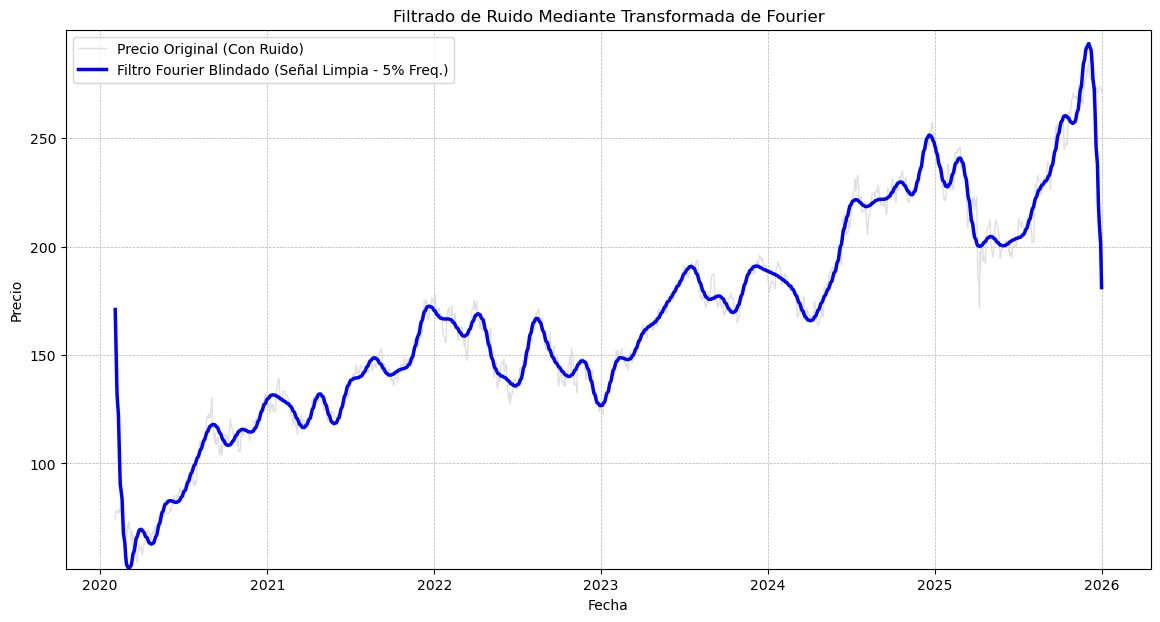

In [21]:
def filtro_fourier_precios_indestructible(serie_precios, porcentaje_frecuencias_a_mantener=0.05):
    serie_limpia = serie_precios.dropna()
    N = len(serie_limpia)
    senal_array = serie_limpia.values
    
    # FFT y frecuencias
    fft_senal = fft(senal_array)
    frecuencias = fftfreq(N)
    
    # Crear máscara 
    freq_absolutas = np.abs(frecuencias)
    umbral_freq = np.percentile(freq_absolutas, porcentaje_frecuencias_a_mantener * 100) # Límite exacto de frecuencia
    
    mascara = freq_absolutas <= umbral_freq # True para mantener, False para silenciar
    
    fft_filtrada = np.zeros_like(fft_senal) # Creamos el array de 0s y copiamos las tendencias de la mascara
    fft_filtrada[mascara] = fft_senal[mascara]
    
    # (IFFT)
    senal_reconstruida = np.real(ifft(fft_filtrada))
    serie_fourier = pd.Series(senal_reconstruida, index=serie_limpia.index)
    
    # Re-alinear con la serie original completa y rellenar nulos finales para que la gráfica sea continua.
    return serie_fourier.reindex(serie_precios.index).ffill().bfill()

# ==========================================
# APLICACIÓN Y VISUALIZACIÓN REVISADA
# ==========================================

df['Close_Clean'] = filtro_fourier_precios_indestructible(df['Close'].iloc[:, 0], porcentaje_frecuencias_a_mantener=0.05)

# Graficamos los resultados
plt.figure(figsize=(14, 7))

# Graficamos el original
plt.plot(df.index, df['Close'], label='Precio Original (Con Ruido)', color='lightgray', alpha=0.7, linewidth=1)

# Graficamos el nuevo filtro 
plt.plot(df.index, df['Close_Clean'], label='Filtro Fourier Blindado (Señal Limpia - 5% Freq.)', color='blue', linewidth=2.5)

plt.title("Filtrado de Ruido Mediante Transformada de Fourier")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.ylim(df['Close'].iloc[:, 0].min() * 0.95, df['Close'].iloc[:, 0].max() * 1.05) # .iloc[:, 0] para extraer los datos como un vector simple de números

plt.show()

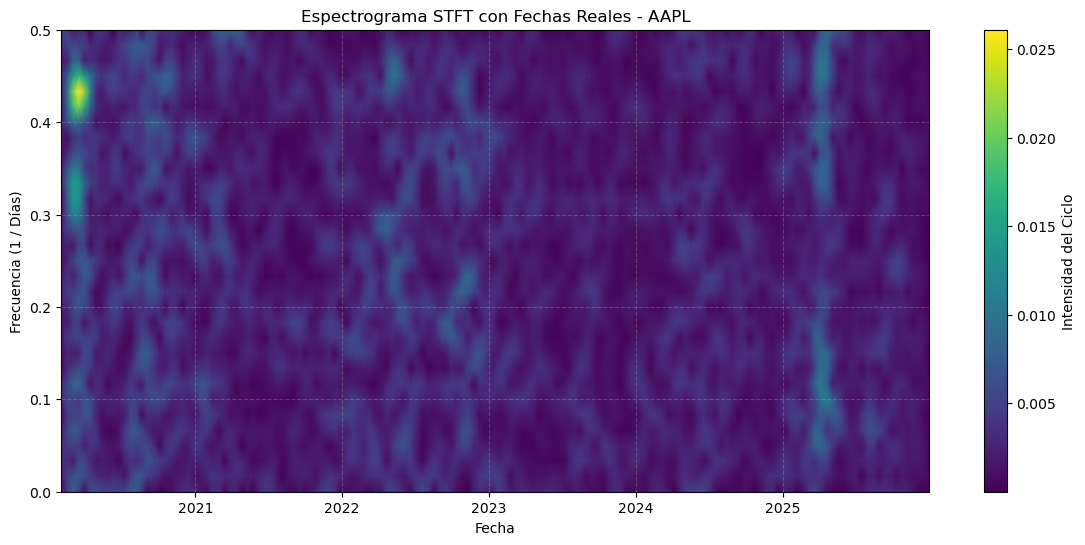

In [22]:
# STFT Análisis de ventana móvil
retornos = df['Returns'].squeeze().dropna() # Unidimensionales y limpios
val_retornos = retornos.values

nperseg = 60 # tamaño de la ventana (días)
noverlap = 50 # solapamiento para suavizar la transicion

# Re-calculamos la STFT (usando los datos que ya tienes)
f, t, Zxx = stft(val_retornos, fs=1.0, nperseg=nperseg, noverlap=noverlap)
potencia = np.abs(Zxx)

# Convertimos los índices de los segmentos de tiempo (t) a fechas reales del DataFrame
# Mapeamos la posición proporcional de 't' sobre el índice cronológico de tus datos
fechas_indices = retornos.index
timestamps_stft = [fechas_indices[min(int(ti), len(fechas_indices)-1)] for ti in t]

# Graficamos el espectrograma mejorado
plt.figure(figsize=(14, 6))

# Pasamos 'timestamps_stft' al eje X para tener fechas reales
plt.pcolormesh(timestamps_stft, f, potencia, shading='gouraud', cmap='viridis')

plt.title(f"Espectrograma STFT con Fechas Reales - {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Frecuencia (1 / Días)")
plt.colorbar(label="Intensidad del Ciclo")
plt.grid(True, alpha=0.3, linestyle='--')

plt.show()

In [23]:
# Modelo Predictivo
# Variables de entrada limpias
ml_df = pd.DataFrame(index=df.index)

ml_df['Volatility'] = df['Volatility'].squeeze()
ml_df['Trend_Fourier'] = df['Close_Clean'].squeeze()
ml_df['Deviation_Fourier'] = df['Close'].squeeze() - df['Close_Clean'].squeeze()

ml_df['Return_lag1'] = df['Returns'].squeeze().shift(1)
ml_df['Return_lag2'] = df['Returns'].squeeze().shift(2)

# Variable objetivo
ml_df['Target'] = np.where(df['Returns'].squeeze().shift(-1) > 0,1,0) # Retorno de mañana +1/-0
ml_df.dropna(inplace=True)

X = ml_df[['Volatility', 'Trend_Fourier', 'Deviation_Fourier', 'Return_lag1', 'Return_lag2']]
y = ml_df['Target']

# División cronologica. Entrenamos con 80% y testeamos con 20%
split_index = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Entrenamiento modelo XGBoost
model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

# Evaluacion
y_pred = model.predict(X_test)

print("Evaluación del modelo")
print(f"Accuracy (precisión global): {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Evaluación del modelo
Accuracy (precisión global): 0.5623
              precision    recall  f1-score   support

           0       0.54      0.31      0.40       137
           1       0.57      0.78      0.66       160

    accuracy                           0.56       297
   macro avg       0.56      0.54      0.53       297
weighted avg       0.56      0.56      0.54       297

